In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img



In [2]:
data_dir = "data"
categorias = ["tiki", "casi_tiki", "descarte"]
augmented_dir = "dataset_ropa_aumentado"

In [5]:
if not os.path.exists(augmented_dir):
    os.makedirs(augmented_dir)
    for category in categorias:
        os.makedirs(os.path.join(augmented_dir, category))

In [3]:
# Parámetros
target_size = (224, 224)
batch_size = 64
num_augmented_images = {"tiki": 15, "casi_tiki": 10, "descarte": 20}

In [7]:
augmentor = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    
    zoom_range=0.4,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

for category in categorias:
    input_folder = os.path.join(data_dir, category)
    output_folder = os.path.join(augmented_dir, category)
    
    for filename in os.listdir(input_folder):
        img_path = os.path.join(input_folder, filename)
        img = load_img(img_path, target_size=target_size)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)
        
        i = 0
        for batch in augmentor.flow(img_array, batch_size=1, save_to_dir=output_folder, save_prefix="aug", save_format="jpeg"):
            i += 1
            if i >= num_augmented_images[category]:
                break

In [4]:
# Generadores de datos
gen_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = gen_datagen.flow_from_directory(
    augmented_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = gen_datagen.flow_from_directory(
    augmented_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 9636 images belonging to 3 classes.
Found 2408 images belonging to 3 classes.


In [ ]:
# base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# base_model.trainable = True 

# for layer in base_model.layers[:140]:
#     layer.trainable = False

In [ ]:
# Construcción del modelo desde cero
model = Sequential()

# Primera capa de convolución
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D((2, 2)))

# Segunda capa de convolución
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Tercera capa de convolución
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Capa de flatten y densa
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(categorias), activation='softmax'))

In [ ]:
optimizer = keras.optimizers.AdamW(learning_rate=0.00001)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
epochs = 50
model.fit(train_generator, validation_data=val_generator, epochs=epochs, callbacks=[early_stopping])
model.save("modelo_ropa_cat.keras")
print("Modelo entrenado y guardado correctamente.")

Epoch 1/50


151/151 [==============================] - 235s 2s/step - loss: 1.0941 - accuracy: 0.4520 - val_loss: 0.9090 - val_accuracy: 0.6200
Epoch 2/50
151/151 [==============================] - 233s 2s/step - loss: 0.8857 - accuracy: 0.5786 - val_loss: 0.7936 - val_accuracy: 0.6910
Epoch 3/50
151/151 [==============================] - 223s 1s/step - loss: 0.7998 - accuracy: 0.6253 - val_loss: 0.7262 - val_accuracy: 0.7072
Epoch 4/50
151/151 [==============================] - 216s 1s/step - loss: 0.7477 - accuracy: 0.6528 - val_loss: 0.6959 - val_accuracy: 0.7168
Epoch 5/50
151/151 [==============================] - 217s 1s/step - loss: 0.7108 - accuracy: 0.6673 - val_loss: 0.6676 - val_accuracy: 0.7205
Epoch 6/50
151/151 [==============================] - 219s 1s/step - loss: 0.6800 - accuracy: 0.6853 - val_loss: 0.6499 - val_accuracy: 0.7197
Epoch 7/50
151/151 [==============================] - 233s 2s/step - loss: 0.6587 - accuracy: 0.6973 - val_loss: 0.6284 - val_accuracy: 0.72

38/38 [==============================] - 36s 912ms/step


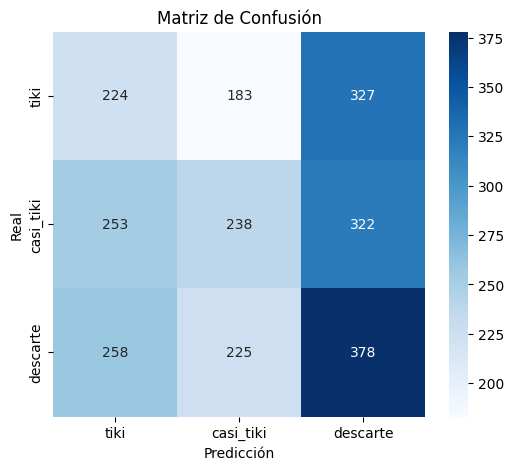

              precision    recall  f1-score   support

        tiki       0.30      0.31      0.30       734
   casi_tiki       0.37      0.29      0.33       813
    descarte       0.37      0.44      0.40       861

    accuracy                           0.35      2408
   macro avg       0.35      0.35      0.34      2408
weighted avg       0.35      0.35      0.35      2408



In [9]:
# Evaluación con matriz de confusión
model = keras.models.load_model("modelo_ropa_cat.keras")
y_true = val_generator.classes
y_pred = np.argmax(model.predict(val_generator), axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categorias, yticklabels=categorias)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

print(classification_report(y_true, y_pred, target_names=categorias))
